In [73]:
from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.types import Send
import operator
from dotenv import load_dotenv
import os

In [74]:
os.environ['LANGCHAIN_PROJECT'] = 'BLOG_WRITING_AGENT_CREATION'

In [75]:
load_dotenv()


llm = ChatOpenAI(
    model="openai/gpt-oss-120b",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
)

In [76]:
class Task(BaseModel):
    id: int
    title: str
    what_to_do: str =  Field(..., description='What to Cover')


In [77]:
class Plan(BaseModel):
    blog_title: str = Field(description="Title of the Blog")
    tasks: list[Task] 

In [78]:
class State(TypedDict):
    topic: str
    plan: Plan
    # reducer: the results from workers get concatenated automatically
    sections : Annotated[list[str], operator.add]

    final: str

In [79]:
llm_with_structured_output = llm.with_structured_output(Plan)

In [80]:
def orchestrator(state: State) -> State:
    plan = llm_with_structured_output.invoke(
        [
            SystemMessage(
                content = 'Generate a comprehensive Blog Plan with 5-7 Sections for the following Blog'
            ),

            HumanMessage(
                content = f"Topic for blog: {state['topic']}"
            )
        ]
    )

    return {
        'plan': plan
    }

In [81]:
def fanout(state: State):
    """
    DYNAMIC FAN-OUT (Map-Reduce) ROUTER
    ====================================
    WHAT THIS DOES:
    - Fanning out means splitting a single workflow execution into multiple 
      parallel tasks that run concurrently.
      
    WHY WE USE IT HERE:
    - Instead of generating section content one task at a time (sequentially), 
      we iterate over all tasks in `state['plan'].tasks` and spawn a dedicated 
      'worker' node for each task simultaneously. This speeds up total runtime.

    WHAT `Send('worker', payload)` DOES:
    - `Send` is LangGraph's primitive for dynamic parallel execution.
    - Argument 1 ('worker'): Specifies the target destination node to run.
    - Argument 2 ({...}): The isolated dictionary (payload) sent into that worker's 
      individual state. Each parallel worker receives its own specific task data.
    """
    return [
        Send('worker', {
            'blog_title': state['plan'].blog_title,
            'task': task,
            'topic': state['topic'],
        })
        for task in state['plan'].tasks
    ]

In [82]:
def worker(payload: dict) -> dict:
    blog_title = payload['blog_title']
    task = payload['task']  
    topic = payload['topic']

    send_md = llm.invoke(
        [
            SystemMessage(content="Write one clean Markdown section."),
            HumanMessage(
                content=(
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.what_to_do}\n\n"
                    "Return only the section content in Markdown."
                )
            )
        ]
    )

    return {
        'sections': [send_md.content]
    }


In [83]:
import re
from pathlib import Path

def reducer(state: State) -> dict:
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    # ---- 1. Sanitize the title for Windows filenames ----
    # Keep only alphanumeric characters and spaces
    clean_title = re.sub(r'[^\w\s-]', '', title).strip()
    # Replace spaces with underscores
    filename = clean_title.lower().replace(" ", "_") + ".md"

    # ---- 2. Save to file ----
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")

    print(f"Successfully saved blog to: {output_path.resolve()}")

    return {"final": final_md}

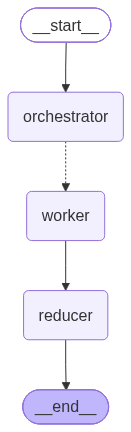

In [84]:
builder = StateGraph(State)

builder.add_node('orchestrator', orchestrator)
builder.add_node('worker', worker)
builder.add_node('reducer', reducer)


builder.add_edge(START, 'orchestrator')
builder.add_conditional_edges('orchestrator', fanout, ['worker'])
builder.add_edge('worker', 'reducer')
builder.add_edge('reducer', END)

graph = builder.compile()

graph

In [85]:
graph.invoke(
    {
        'topic': 'Write a blog on Self Attention'
    }
)



Successfully saved blog to: D:\Summer-2026\llm-engineering-lab\Practice Codes\Week 3\Day 4\Blog Writing Agent\understanding_selfattention_the_engine_behind_modern_ai_transformers.md


{'topic': 'Write a blog on Self Attention',
 'plan': Plan(blog_title='Understanding Self‑Attention: The Engine Behind Modern AI Transformers', tasks=[Task(id=1, title='1️⃣ Introduction – Why Self‑Attention Matters', what_to_do='* Hook the reader with a real‑world example (e.g., language translation, image captioning) where traditional RNNs/CNNs struggle.\n* Briefly define self‑attention in one sentence.\n* State the goal of the post: demystify the concept, its math, and why it’s a game‑changer for NLP and beyond.\n* Promise a step‑by‑step journey from intuition to implementation.'), Task(id=2, title='2️⃣ The Intuition Behind Self‑Attention', what_to_do='* Explain the ‘paying attention’ metaphor – each token looks at every other token.\n* Use a simple analogy (e.g., reading a paragraph and remembering earlier words while interpreting a later one).\n* Visual\u202faid suggestion: diagram of a sentence with arrows showing attention weights.\n* Highlight key ideas: context‑dependent represe